# **64.1: [CO4] Perform Customer Segmentation with Scikit-learn**

Setup & Data Load

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Loading datasets

In [ ]:
mock_users = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_users.csv')
mock_quizzes = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_quizzes.csv')

print(mock_users.head())
print(mock_quizzes.head())

  user_id signup_date         user_persona subscription_plan last_login_date  \
0  QF1000  03-03-2024  High School Teacher              Free      30-08-2024   
1  QF1001  03-03-2024  High School Teacher        Enterprise      17-08-2024   
2  QF1002  03-04-2024      Content Creator               Pro      13-08-2024   
3  QF1003  03-05-2024  Language Instructor              Free      29-08-2024   
4  QF1004  03-06-2024      HR Professional              Free      14-08-2024   

   quizzes_created  is_active signup_month  days_since_signup  \
0                7      False      2024-03                181   
1               65       True      2024-03                181   
2               15       True      2024-03                180   
3                8       True      2024-03                179   
4                2       True      2024-03                178   

   days_since_last_login  
0                      5  
1                     14  
2                     18  
3                   

Feature Engineering

In [ ]:
# Derive number of quizzes created by each user
quiz_counts = mock_quizzes.groupby('creator_id')['quiz_id'].count().reset_index()
quiz_counts.columns = ['creator_id', 'quizzes_created']

# Merge with user data
users_features = mock_users.merge(quiz_counts, left_on='user_id', right_on='creator_id', how='left')

# Fill missing values from both possible sources
if 'quizzes_created_x' in users_features.columns and 'quizzes_created_y' in users_features.columns:
    # Combine: if quizzes_created_y is NaN, use quizzes_created_x
    users_features['quizzes_created'] = users_features['quizzes_created_y'].fillna(users_features['quizzes_created_x'])
    users_features.drop(columns=['quizzes_created_x', 'quizzes_created_y'], inplace=True)
elif 'quizzes_created_y' in users_features.columns:
    users_features.rename(columns={'quizzes_created_y': 'quizzes_created'}, inplace=True)
elif 'quizzes_created_x' in users_features.columns:
    users_features.rename(columns={'quizzes_created_x': 'quizzes_created'}, inplace=True)

# Drop creator_id since it’s just for merging
users_features.drop(columns=['creator_id'], inplace=True, errors='ignore')

# Fill missing quiz counts with 0
users_features['quizzes_created'] = users_features['quizzes_created'].fillna(0)

# Compute tenure (days since signup)
users_features['signup_date'] = pd.to_datetime(users_features['signup_date'], errors='coerce')
users_features['tenure_days'] = (pd.Timestamp.now() - users_features['signup_date']).dt.days

users_features.head()

,user_id,signup_date,user_persona,subscription_plan,last_login_date,is_active,signup_month,days_since_signup,days_since_last_login,quizzes_created,tenure_days
0,QF1000,2024-03-03,High School Teacher,Free,30-08-2024,False,2024-03,181,5,4.0,603.0
1,QF1001,2024-03-03,High School Teacher,Enterprise,17-08-2024,True,2024-03,181,14,11.0,603.0
2,QF1002,2024-03-04,Content Creator,Pro,13-08-2024,True,2024-03,180,18,2.0,602.0
3,QF1003,2024-03-05,Language Instructor,Free,29-08-2024,True,2024-03,179,2,2.0,601.0
4,QF1004,2024-03-06,HR Professional,Free,14-08-2024,True,2024-03,178,17,2.0,600.0


Data Preprocessing

In [ ]:
X = users_features[['quizzes_created', 'tenure_days']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.09272672,  1.35261867],
       [ 2.11480462,  1.35261867],
       [-0.48500983,  1.33945922],
       [-0.48500983,  1.32629978],
       [-0.48500983,  1.31314033]])

Determine Optimal Number of Clusters (Elbow Method)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = users_features[['quizzes_created', 'tenure_days']].copy()

X = X.fillna(0)   # Option 1: Replace NaN with 0
# or X = X.fillna(X.mean())  # Option 2: Replace with column means (better if 0 is not meaningful)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

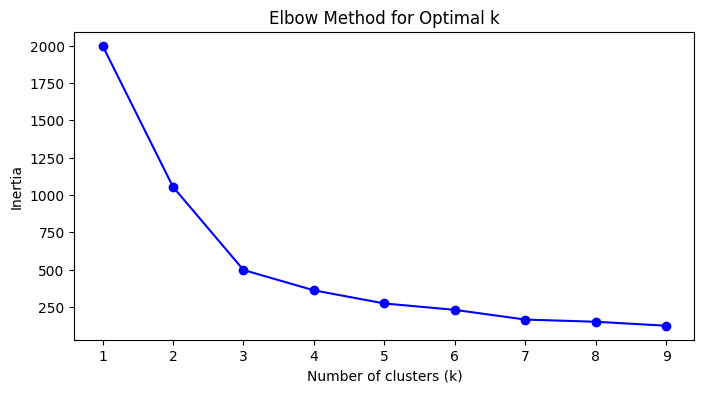

In [ ]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Run KMeans Clustering

In [ ]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
users_features['segment'] = kmeans.fit_predict(X_scaled)

users_features[['user_id', 'quizzes_created', 'tenure_days', 'segment']].head()

,user_id,quizzes_created,tenure_days,segment
0,QF1000,4.0,603.0,1
1,QF1001,11.0,603.0,0
2,QF1002,2.0,602.0,1
3,QF1003,2.0,601.0,1
4,QF1004,2.0,600.0,1


Visualize Clusters

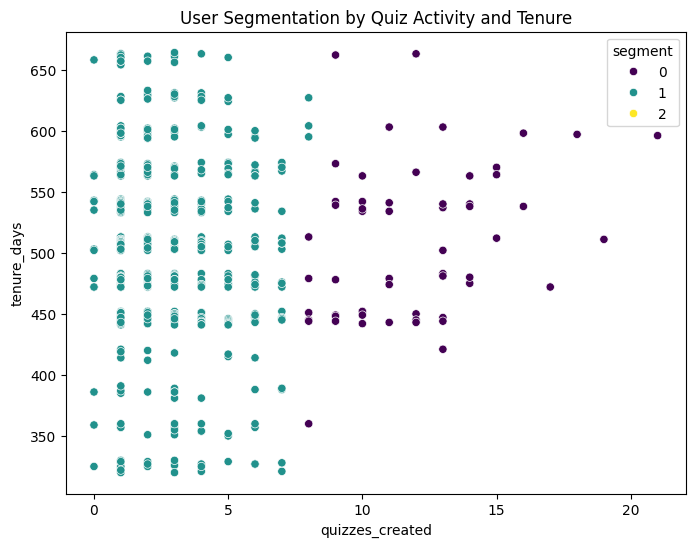

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='quizzes_created',
    y='tenure_days',
    hue='segment',
    palette='viridis',
    data=users_features
)
plt.title('User Segmentation by Quiz Activity and Tenure')
plt.show()

In [ ]:
users_features.to_csv('/content/mock_users_with_segments.csv', index=False)
print("Saved mock_users_with_segments.csv successfully!")

Saved mock_users_with_segments.csv successfully!


# **65.1: [CO4] Analyze and Profile User Segments**

Loading the segmented dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/content/drive/MyDrive/64.1 Quiz Forge/mock_users_with_segments.csv')

# Quick check
df.head()

,user_id,signup_date,user_persona,subscription_plan,last_login_date,is_active,signup_month,days_since_signup,days_since_last_login,quizzes_created,tenure_days,segment
0,QF1000,2024-03-03,High School Teacher,Free,30-08-2024,False,2024-03,181,5,4.0,603.0,1
1,QF1001,2024-03-03,High School Teacher,Enterprise,17-08-2024,True,2024-03,181,14,11.0,603.0,0
2,QF1002,2024-03-04,Content Creator,Pro,13-08-2024,True,2024-03,180,18,2.0,602.0,1
3,QF1003,2024-03-05,Language Instructor,Free,29-08-2024,True,2024-03,179,2,2.0,601.0,1
4,QF1004,2024-03-06,HR Professional,Free,14-08-2024,True,2024-03,178,17,2.0,600.0,1


Summarize Each Segment

In [2]:
segment_summary = df.groupby('segment').agg({
    'quizzes_created': ['mean', 'median', 'max'],
    'tenure_days': ['mean', 'median'],
    'user_persona': lambda x: x.value_counts().index[0],
    'subscription_plan': lambda x: x.value_counts().index[0]
}).round(2)

segment_summary

quizzes_created              tenure_days                user_persona  \
                   mean median   max        mean median             <lambda>   
segment                                                                        
0                 12.27   12.0  21.0      508.04  506.5  High School Teacher   
1                  2.70    2.0   8.0      499.42  503.0  High School Teacher   
2                  2.87    2.0   8.0         NaN    NaN  High School Teacher   

        subscription_plan  
                 <lambda>  
segment                    
0              Enterprise  
1                    Free  
2                    Free

Flattening column names for neatness

In [3]:
segment_summary.columns = ['_'.join(col).strip() for col in segment_summary.columns.values]
segment_summary.reset_index(inplace=True)
segment_summary

,segment,quizzes_created_mean,quizzes_created_median,quizzes_created_max,tenure_days_mean,tenure_days_median,user_persona_<lambda>,subscription_plan_<lambda>
0,0,12.27,12.0,21.0,508.04,506.5,High School Teacher,Enterprise
1,1,2.70,2.0,8.0,499.42,503.0,High School Teacher,Free
2,2,2.87,2.0,8.0,NaN,NaN,High School Teacher,Free


### **Visualizing Key Differences**

Quizzes Created by Segment

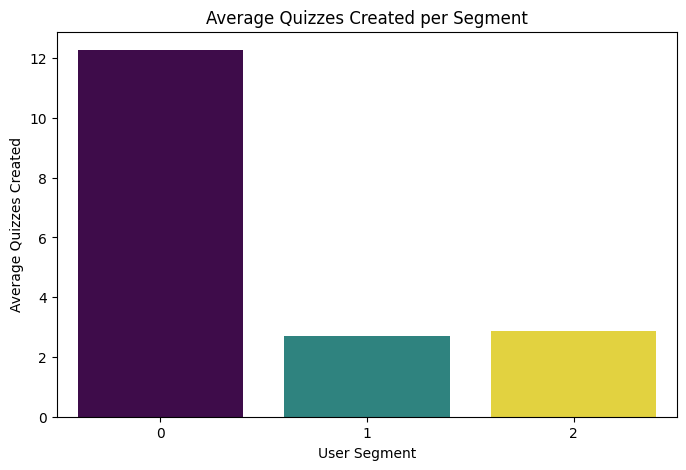

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='segment', y='quizzes_created', hue='segment', legend=False, estimator='mean', errorbar=None, palette='viridis')
plt.title('Average Quizzes Created per Segment')
plt.xlabel('User Segment')
plt.ylabel('Average Quizzes Created')
plt.show();

Tenure Comparison

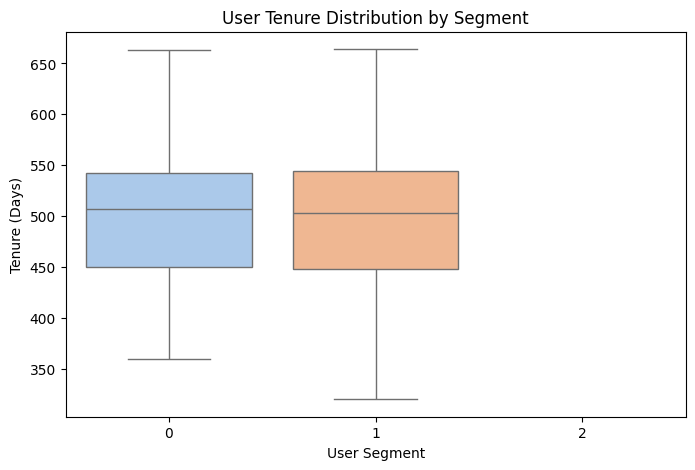

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='segment', hue='segment', y='tenure_days', palette='pastel', legend=False)
plt.title('User Tenure Distribution by Segment')
plt.xlabel('User Segment')
plt.ylabel('Tenure (Days)')
plt.show()

Persona Composition per Segment

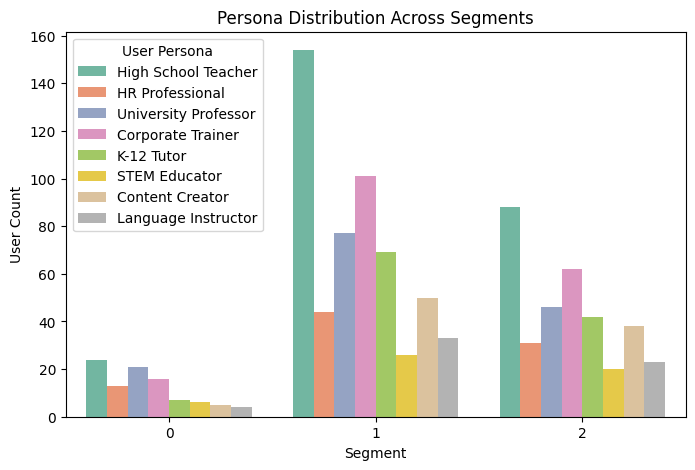

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='segment', hue='user_persona', palette='Set2')
plt.title('Persona Distribution Across Segments')
plt.xlabel('Segment')
plt.ylabel('User Count')
plt.legend(title='User Persona')
plt.show()

### Segment 0 – Power Educators

**Behavioral Summary**:
This segment shows the highest quiz creation activity with an average of 12.3 quizzes created per user, far exceeding other groups.
Tenure averages around 508 days, suggesting long-term engagement and strong platform familiarity.
#
**User Persona Insight**:
Predominantly High School Teachers, often using QuizForge as part of their regular teaching workflow.
Most are on the Enterprise plan, indicating institutional adoption.
#
**Business Interpretation**:
These are core creators — they generate a large share of total content and demonstrate strong retention.
They represent QuizForge’s champion user base, ideal for pilot testing advanced AI quiz generation tools or referral campaigns.

### Segment 1 – Steady Contributors

**Behavioral Summary:**
This group shows moderate engagement, averaging 2.7 quizzes created per user and tenure of about 499 days.
Activity levels are consistent but not as high as Segment 0.
#
**User Persona Insight:**
Also dominated by High School Teachers, but primarily using the Free plan, suggesting limited investment in premium tools.
A portion of users are active on the platform regularly but in smaller bursts.
#
**Business Interpretation:**
This is the conversion opportunity group.
These users are comfortable with QuizForge but haven’t committed financially — targeted messaging and value-based nudges could drive Free → Paid plan upgrades.

### Segment 2 – Emerging Users

**Behavioral Summary:**
The smallest and least active cluster with roughly 2.9 quizzes created per user and limited tenure data (incomplete or shorter usage histories).
#
**User Persona Insight:**
Primarily High School Teachers and early sign-ups on Free plans. Engagement is still forming — likely newer users or those exploring features casually.
#
**Business Interpretation:**
This group represents onboarding and activation focus.
Encouraging first content creation, providing guided tutorials, or offering quick AI quiz templates could help turn these users into consistent creators.

###Strategic Takeaways

**Segment 0 (Power Educators)** are the backbone of platform content creation and retention.
Prioritize them for beta testing and community recognition programs.
#
**Segment 1 (Steady Contributors)** are the key revenue growth segment.
With tailored upgrade incentives (e.g., extra AI tokens, custom branding), they can easily convert to paid tiers.
#
**Segment 2 (Emerging Users)** need structured onboarding and engagement loops to prevent churn.
Automating “Welcome + First Quiz Challenge” workflows could boost activation rates significantly.
#
**Overall:** The segmentation reveals a clear progression path — Emerging → Steady → Power.
Aligning marketing and feature rollout strategies along this maturity curve will maximize retention and monetization.